In [1]:
pip install --upgrade uproot matplotlib pandas  scipy scikit-learn seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: C:\Users\Dama_Kamama\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
### standard sci-py libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import uproot ### to read, convert, inspect ROOT TTrees
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Importing Data 

In [3]:
import uproot
import pandas as pd  # Import the pandas library

# Rest of your code remains unchanged
#mc_file = uproot.open("/home/oem/repos/data/AnalysisResults_reduced.root")
mc_file = uproot.open("AnalysisResults_reduced.root")
# mc_file = uproot.open("~/github/data/AnalysisResults_reduced.root")

# Load the data from the "XiOmegaTree" TTree using NumPy arrays
numpy_mc = mc_file["XiOmegaTree"].arrays(library="np")

In [4]:
# Convert the NumPy arrays to a pandas DataFrame
AnalysisResults_reduced = pd.DataFrame(numpy_mc)
# Write the DataFrame to a CSV file
#df.to_csv("AnalysisResults-mc_reduced.csv", index=False)

# file  2


In [5]:
#mc_file2 = uproot.open("/home/oem/repos/data/AnalysisResults-mc_reduced.root")
mc_file2 = uproot.open("AnalysisResults-mc_reduced.root")
#mc_file2 = uproot.open("~/github/data/AnalysisResults-mc_reduced.root")

mc_file2.keys()

# Load the data from the "XiOmegaTree" TTree using NumPy arrays
numpy_mc2 = mc_file2["XiOmegaTree"].arrays(library="np")

In [6]:
# Convert the NumPy arrays to a pandas DataFrame
AnalysisResultsmc_reduced = pd.DataFrame(numpy_mc2)
# Write the DataFrame to a CSV file
#AnalysisResults_mc_reduced.to_csv("AnalysisResults-mc_reduced.csv", index=False)

In [7]:
AnalysisResultsmc_reduced =  AnalysisResultsmc_reduced.iloc[:1000, :] # comment this line to run code with wholee data
AnalysisResults_reduced =  AnalysisResults_reduced.iloc[:1000, :] # cpomment this line to run whole code with whole data

# ABOUT THE DATA



**1. pt (Transverse Momentum):** The transverse momentum, represented by the column "pt," encapsulates the momentum component perpendicular to the direction of motion of particles within a particle collision. In the context of our analysis, it's akin to the sideways force exerted on an object as it moves forward. Just as a car may experience a lateral push while traveling along a straight path, particles exhibit transverse momentum as they navigate through space within the collision environment. This momentum component is essential for understanding the trajectories and interactions of particles, contributing valuable insights into their behavior and properties during the collision process.

**2. eta (Pseudorapidity):** Pseudorapidity, denoted by the column "eta," serves as a measure of the angle of a particle's trajectory relative to the beam axis within a particle collider. It provides crucial information about the distribution of particles across different regions of the detector. Think of pseudorapidity as analogous to the inclination angle of an object on a slope. Just as the steepness of a hill affects the trajectory of a rolling ball, pseudorapidity influences the distribution of particles within the detector, impacting their observable characteristics and interactions during collision events.

**3. mass (Mass):** The mass column represents the amount of matter contained within particles participating in collision events. Similar to the weight of an object, mass indicates the intrinsic property defining the particle's resistance to changes in motion. In our analysis, mass serves as a fundamental parameter for characterizing particle properties and interactions. Much like how the weight of an object determines its behavior under gravitational forces, particle mass influences their trajectories, decay patterns, and interactions within the collision environment, offering valuable insights into their underlying properties and behavior.

**4. ct (Decay Length):** Decay length, as indicated by the "ct" column, measures the distance traveled by particles before undergoing decay processes. It's akin to the distance covered by a thrown object before hitting the ground. Within the context of particle physics, decay length provides essential information about the stability and lifetime of particles, influencing their observable signatures and detection probabilities within the experimental setup. Understanding decay lengths enables researchers to infer crucial details about particle lifetimes, decay modes, and underlying interaction mechanisms, contributing to our comprehension of fundamental particle properties and behavior.

**5. radius (Radius):** The radius column denotes the distance from the center to the edge of a particle's trajectory within the detector. Similar to the radius of a circle, it characterizes the size and spatial extent of particle trajectories observed during collision events. Understanding particle radii provides insights into their spatial distribution and interaction patterns within the detector environment. Much like how the radius of a circular object defines its size and boundary, particle radii delineate the spatial boundaries of particle trajectories, aiding in the identification and classification of particles based on their observable signatures.

**6. radiusV0 (Radius V0):** RadiusV0 signifies the radius of a specific region of interest within the particle collision environment. Analogous to the radius of a target area within a larger space, it delineates a distinct region within the detector where specific particle interactions or decay processes are of interest. By focusing on the radiusV0 region, researchers can zoom in on specific particle interactions or phenomena, enabling targeted analysis and investigation of underlying processes. This localized perspective offers valuable insights into the dynamics and characteristics of particles within the designated region, enhancing our understanding of particle interactions and properties within the broader collision environment.

**7. dcaBachPV (Distance of Closest Approach to Bachelor Particle Primary Vertex):** The dcaBachPV column represents the closest distance between a particle track and the primary vertex associated with the bachelor particle. It's analogous to the minimum separation between two entities within the particle collision environment. This parameter provides essential information about the spatial relationships between particles and primary vertices, offering insights into particle trajectories and interaction patterns. Similar to how the distance between two points defines their spatial proximity, dcaBachPV quantifies the proximity between particle tracks and primary vertices, aiding in the characterization and classification of particle interactions within the detector.

**8. dcaV0PV (Distance of Closest Approach to V0 Particle Primary Vertex):** DcaV0PV measures the closest distance between a particle track and the primary vertex associated with the V0 particle. It's akin to the shortest distance between a particle's trajectory and a reference point within the collision environment. This parameter provides crucial information about the spatial relationship between particles and primary vertices, enabling researchers to infer valuable insights into particle trajectories and interaction dynamics. Much like how the distance between two points defines their spatial relationship, dcaV0PV quantifies the proximity between particle tracks and V0 particle primary vertices, facilitating the analysis and interpretation of particle interactions within the experimental setup.

**9. dcaV0piPV (Distance of Closest Approach to V0 Pion Primary Vertex):** The dcaV0piPV column denotes the closest distance between a particle track and the primary vertex associated with the V0 pion. It's similar to the minimum separation between two points within the particle collision environment. This parameter provides essential information about the spatial relationships between particles and primary vertices, offering insights into particle trajectories and interaction patterns. Much like how the distance between two points defines their spatial proximity, dcaV0piPV quantifies the proximity between particle tracks and primary vertices, aiding in the characterization and classification of particle interactions within the detector.

**10. dcaV0prPV (Distance of Closest Approach to V0 Proton Primary Vertex):** DcaV0prPV measures the closest distance between a particle track and the primary vertex associated with the V0 proton. It's similar to the shortest distance between a particle's trajectory and a reference point within the collision environment. This parameter provides crucial information about the spatial relationship between particles and primary vertices, enabling researchers to infer valuable insights into particle trajectories and interaction dynamics. Much like how the distance between two points defines their spatial relationship, dcaV0prPV quantifies the proximity between particle tracks and V0 particle primary vertices, facilitating the analysis and interpretation of particle interactions within the experimental setup.

# Data Cleaning and Preprocessing:  

## SIMULATED DATA

### 1. MISSING VALUES

The message "No missing values found in the DataFrame" indicates that after examining each column in the DataFrame `AnalysisResultsmc_reduced`, no missing values were detected. This suggests that all data entries in the DataFrame have been properly populated, with no null or NaN values present. It implies that the dataset is complete and ready for analysis without the need for additional data imputation or cleaning steps.

In [8]:
# Check for missing values in each column
missing_values = AnalysisResultsmc_reduced.isna().sum()

# Display the columns with missing values, if any
columns_with_missing_values = missing_values[missing_values > 0]

In [9]:
# Downcast numeric types
for col in AnalysisResultsmc_reduced.select_dtypes(include=['int', 'float']).columns:
    AnalysisResultsmc_reduced[col] = pd.to_numeric(AnalysisResultsmc_reduced[col], downcast='float')

# Convert categorical columns to category data type
for col in AnalysisResultsmc_reduced.select_dtypes(include=['object']).columns:
    AnalysisResultsmc_reduced[col] = AnalysisResultsmc_reduced[col].astype('category')


### 2. outliers, and inconsistencies.

In [10]:
# Filter columns with integer values
integer_columns = AnalysisResultsmc_reduced.select_dtypes(exclude='object').columns

# Create a new DataFrame with only integer columns
AnalysisResultsmc_reduced_integer = AnalysisResultsmc_reduced[integer_columns]

# Descriptive statistics
#integer_describe = AnalysisResultsmc_reduced_integer.describe()
#print(integer_describe)

# Box plot for each integer column
#import matplotlib.pyplot as plt
#plt.figure(figsize=(10, 6))
#AnalysisResultsmc_reduced_integer.boxplot()
#plt.title('Box plot of Integer Columns')
#plt.ylabel('Value')
#plt.xlabel('Columns')
#plt.xticks(rotation=45)
#plt.show()


In [11]:
# Filter columns with integer values
integer_columns = AnalysisResultsmc_reduced.select_dtypes(exclude='object').columns

# Create a new DataFrame with only integer columns
AnalysisResultsmc_reduced_integer = AnalysisResultsmc_reduced[integer_columns]

from scipy.stats import zscore

# Calculate z-score for each value in integer columns
z_scores = AnalysisResultsmc_reduced_integer.apply(zscore)

# Define threshold for outlier detection
threshold = 3

# Find outliers
outliers = (z_scores > threshold) | (z_scores < -threshold)


In [12]:
# Downcast numeric types
for col in AnalysisResultsmc_reduced.select_dtypes(include=['int', 'float']).columns:
    AnalysisResultsmc_reduced[col] = pd.to_numeric(AnalysisResultsmc_reduced[col], downcast='float')

# Convert categorical columns to category data type
for col in AnalysisResultsmc_reduced.select_dtypes(include=['object']).columns:
    AnalysisResultsmc_reduced[col] = AnalysisResultsmc_reduced[col].astype('category')


### 3. STANDERDIZATION AND NORMALIZATION

In [13]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
# Initialize the StandardScaler
scaler = StandardScaler()

# Standardize the data
standardized_data = scaler.fit_transform(AnalysisResultsmc_reduced)
# Assuming standardized_data is the standardized array and AnalysisResultsmc_reduced is the DataFrame
standardized_df = pd.DataFrame(standardized_data, columns=AnalysisResultsmc_reduced.columns)

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Normalize the standardized data
normalized_data = scaler.fit_transform(standardized_df)

# Convert the normalized data back to a DataFrame
normalized_df = pd.DataFrame(normalized_data, columns=AnalysisResultsmc_reduced.columns)

## 2. REAL DATA

### 1.MISSING VALUES

In [15]:
# Check for missing values in each column AnalysisResults_reduced
missing_values = AnalysisResults_reduced.isna().sum()

# Display the columns with missing values, if any
columns_with_missing_values = missing_values[missing_values > 0]
if not columns_with_missing_values.empty:
    print("Columns with missing values:")
    print(columns_with_missing_values)
else:
    print("No missing values found in the DataFrame.")

No missing values found in the DataFrame.


### 2. OUTLIERS AND INCONCISTSNECIES

In [16]:

# Filter columns with integer values
integer_columns = AnalysisResults_reduced.select_dtypes(exclude='object').columns

# Create a new DataFrame with only integer columns
AnalysisResults_reduced_integer = AnalysisResults_reduced[integer_columns]

# Descriptive statistics
#integer_describe = AnalysisResults_reduced_integer.describe()
#print(integer_describe)

# Box plot for each integer column
#import matplotlib.pyplot as plt
#plt.figure(figsize=(10, 6))
#AnalysisResults_reduced_integer.boxplot()
#plt.title('Box plot of Integer Columns')
#plt.ylabel('Value')
#plt.xlabel('Columns')
#plt.xticks(rotation=45)
#plt.show()




# Filter columns with integer values
integer_columns = AnalysisResults_reduced.select_dtypes(exclude='object').columns

# Create a new DataFrame with only integer columns
AnalysisResults_reduced_integer = AnalysisResults_reduced[integer_columns]

from scipy.stats import zscore

# Calculate z-score for each value in integer columns
z_scores = AnalysisResults_reduced_integer.apply(zscore)

# Define threshold for outlier detection
threshold = 3

# Find outliers
outliers = (z_scores > threshold) | (z_scores < -threshold)

# Display outliers
print("Outliers:")
print(outliers)


Outliers:
        pt    eta   mass     ct  radius  radiusV0  dcaBachPV  dcaV0PV  \
0    False  False  False  False   False     False      False    False   
1    False  False  False  False   False     False      False    False   
2    False  False  False  False   False     False      False    False   
3    False  False  False  False   False     False      False    False   
4    False  False  False  False   False     False      False    False   
..     ...    ...    ...    ...     ...       ...        ...      ...   
995  False  False  False  False   False     False      False    False   
996  False  False  False  False   False     False      False    False   
997  False  False  False  False   False     False      False    False   
998  False  False  False  False   False     False      False    False   
999  False  False  False  False   False     False      False    False   

     dcaV0piPV  dcaV0prPV  ...  bachBarCosPA  tpcClBach  tpcClV0Pr  tpcClV0Pi  \
0        False      False  ...  

C:\Users\Dama_Kamama\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pandas\core\apply.py:1081: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)


### 3. STANDARDIZATION AND NORMALIZATION

In [17]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Standardize the data
standardized_data = scaler.fit_transform(AnalysisResults_reduced)
# Assuming standardized_data is the standardized array and AnalysisResults_reduced is the DataFrame
standardized_df_real = pd.DataFrame(standardized_data, columns=AnalysisResults_reduced.columns)



In [18]:

from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Normalize the standardized data
normalized_data = scaler.fit_transform(standardized_df_real)

# Convert the normalized data back to a DataFrame
normalized_df_real = pd.DataFrame(normalized_data, columns=AnalysisResults_reduced.columns)

# EDA
## simulated data

                pt          eta         mass           ct       radius  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.346197     0.502361     0.355471     0.044423     0.322112   
std       0.172327     0.256532     0.407560     0.101737     0.319649   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.208603     0.303828     0.063455     0.008299     0.075697   
50%       0.334491     0.500575     0.094696     0.017826     0.191235   
75%       0.467570     0.713962     0.911027     0.036800     0.467131   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

          radiusV0    dcaBachPV      dcaV0PV    dcaV0piPV    dcaV0prPV  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.757190     0.429906     0.303884     0.752273     0.380427   
std       0.308032     0.368121     0.324204     0.330491     0.331681   
min       0.000000     0.000000     0

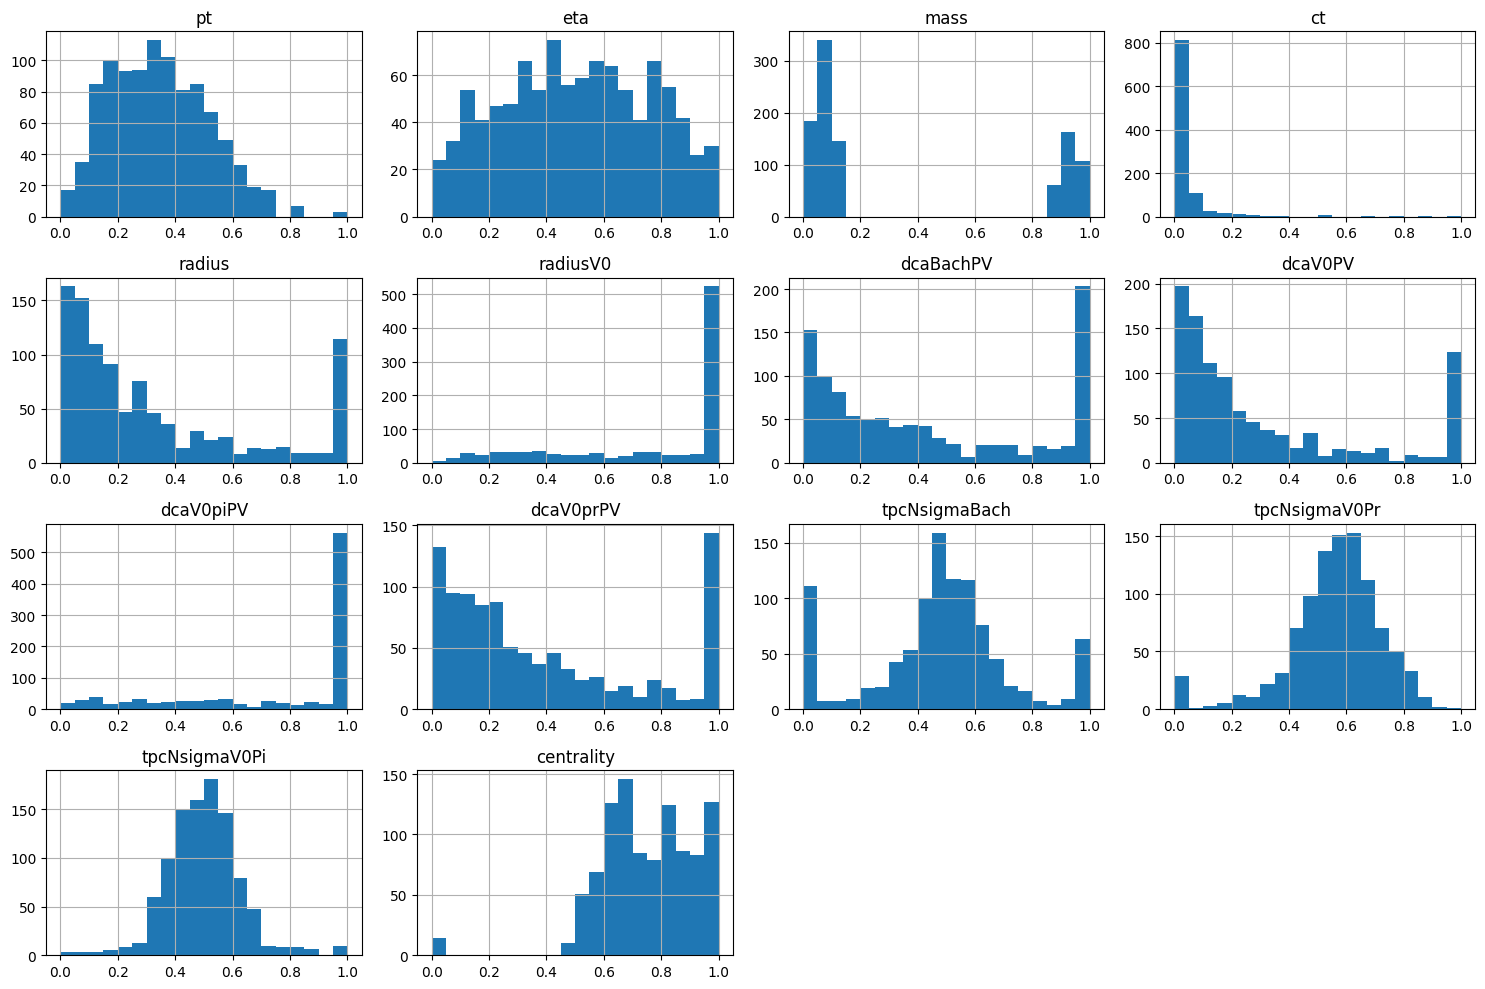

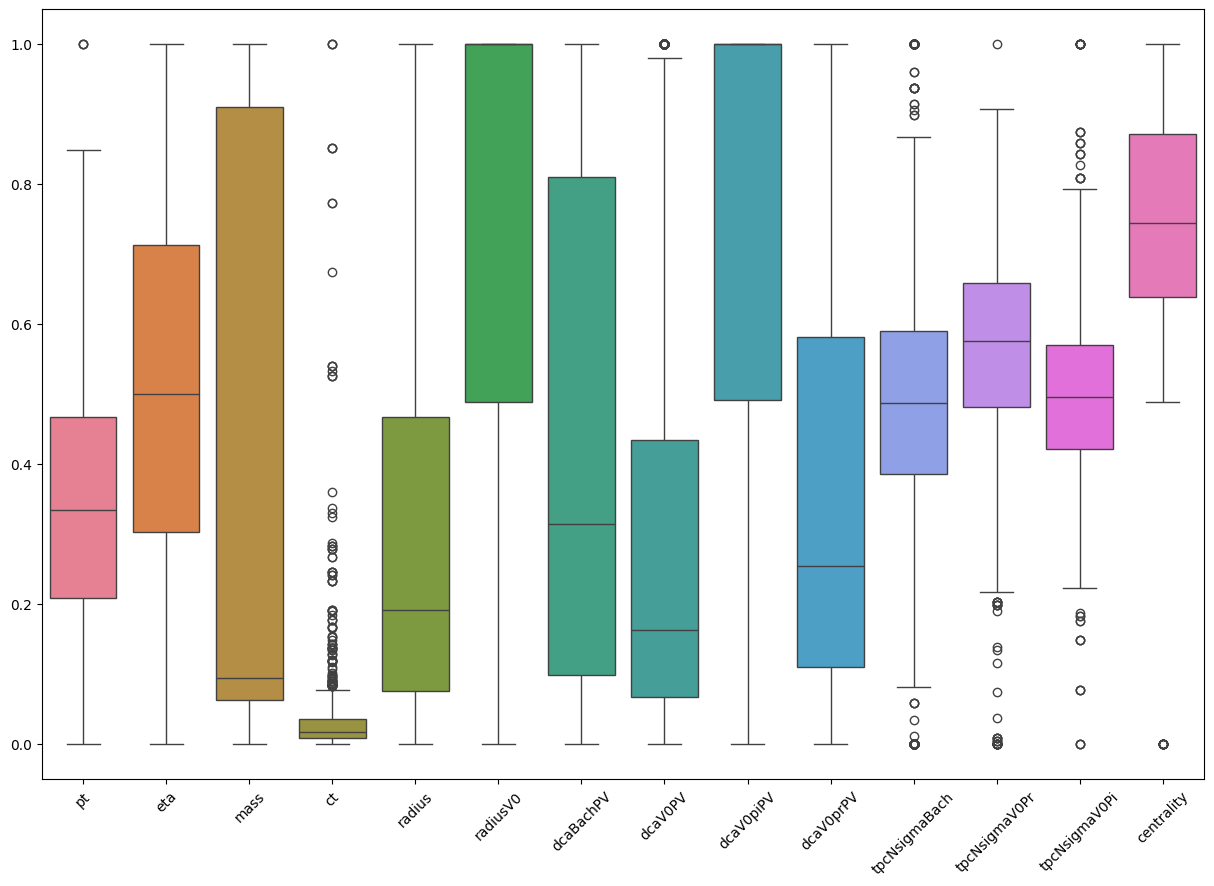

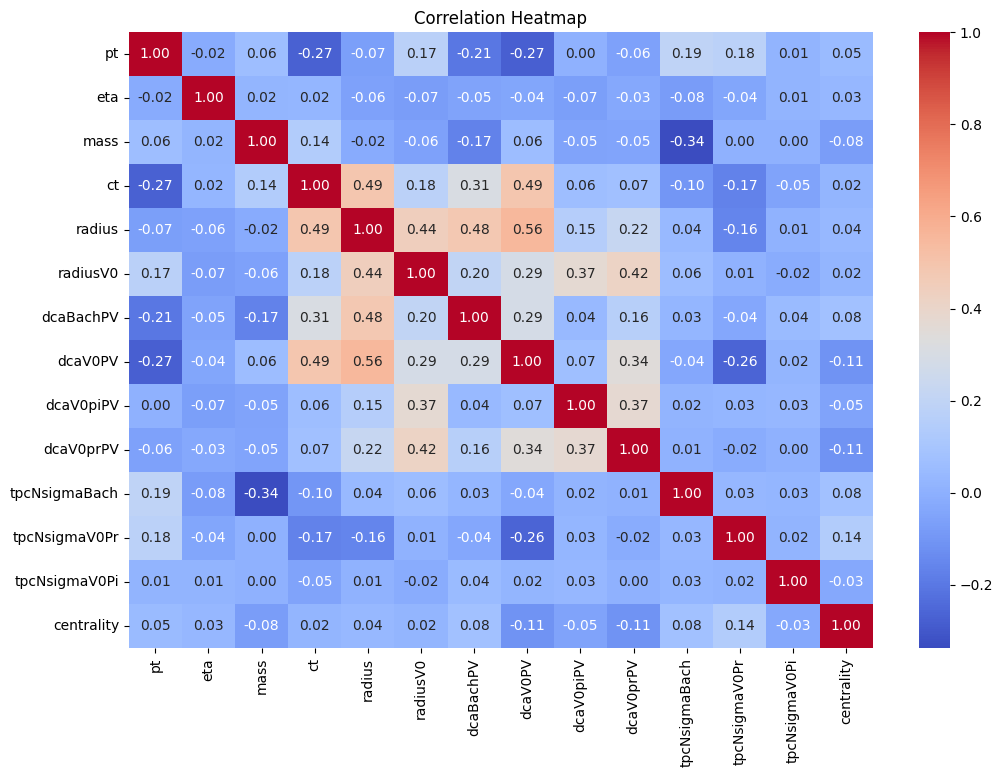

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Subset of columns for EDA (you can modify this list based on your specific requirements)
columns_subset = ['pt', 'eta', 'mass', 'ct', 'radius', 'radiusV0', 'dcaBachPV', 'dcaV0PV', 'dcaV0piPV',
                  'dcaV0prPV', 'tpcNsigmaBach', 'tpcNsigmaV0Pr', 'tpcNsigmaV0Pi', 'centrality']

# Descriptive statistics
print(normalized_df[columns_subset].describe())

# Histograms
normalized_df[columns_subset].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(15, 10))
sns.boxplot(data=normalized_df[columns_subset])
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap
correlation_matrix = normalized_df[columns_subset].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## REAL DATA

                pt          eta         mass           ct       radius  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.309657     0.503539     0.504954     0.345967     0.150382   
std       0.140554     0.259158     0.286290     0.249423     0.131150   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.214800     0.273423     0.262121     0.152384     0.056911   
50%       0.292473     0.507013     0.512879     0.276085     0.113821   
75%       0.387073     0.733717     0.750280     0.491290     0.211382   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

          radiusV0    dcaBachPV      dcaV0PV    dcaV0piPV    dcaV0prPV  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.552978     0.247565     0.360711     0.683521     0.292106   
std       0.375610     0.266185     0.300505     0.359447     0.283648   
min       0.000000     0.000000     0

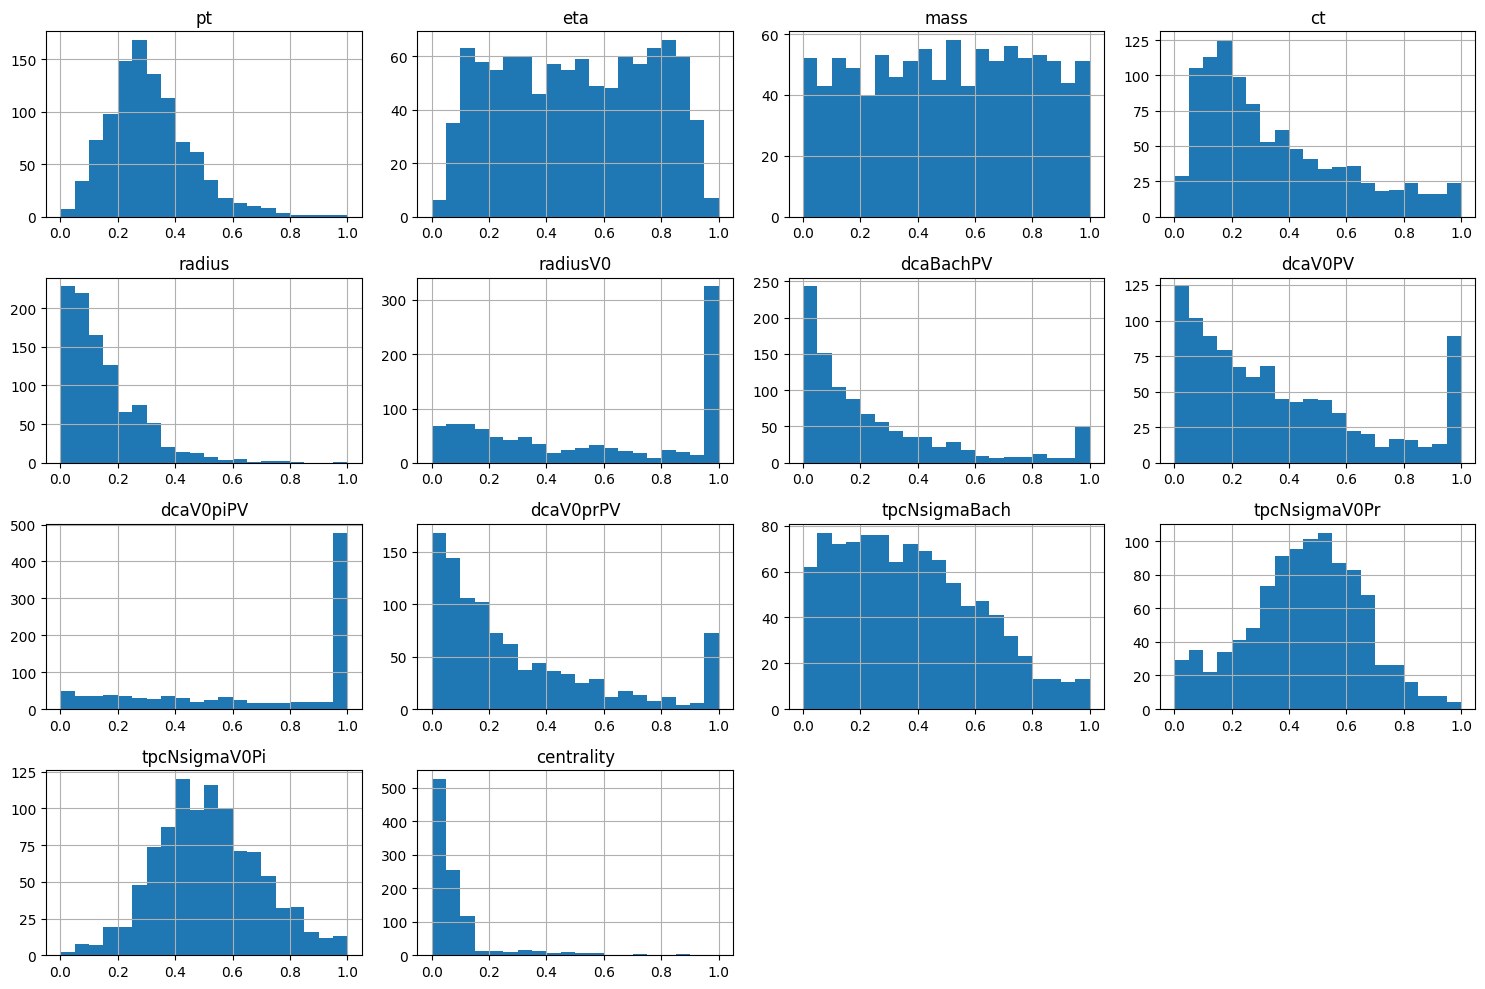

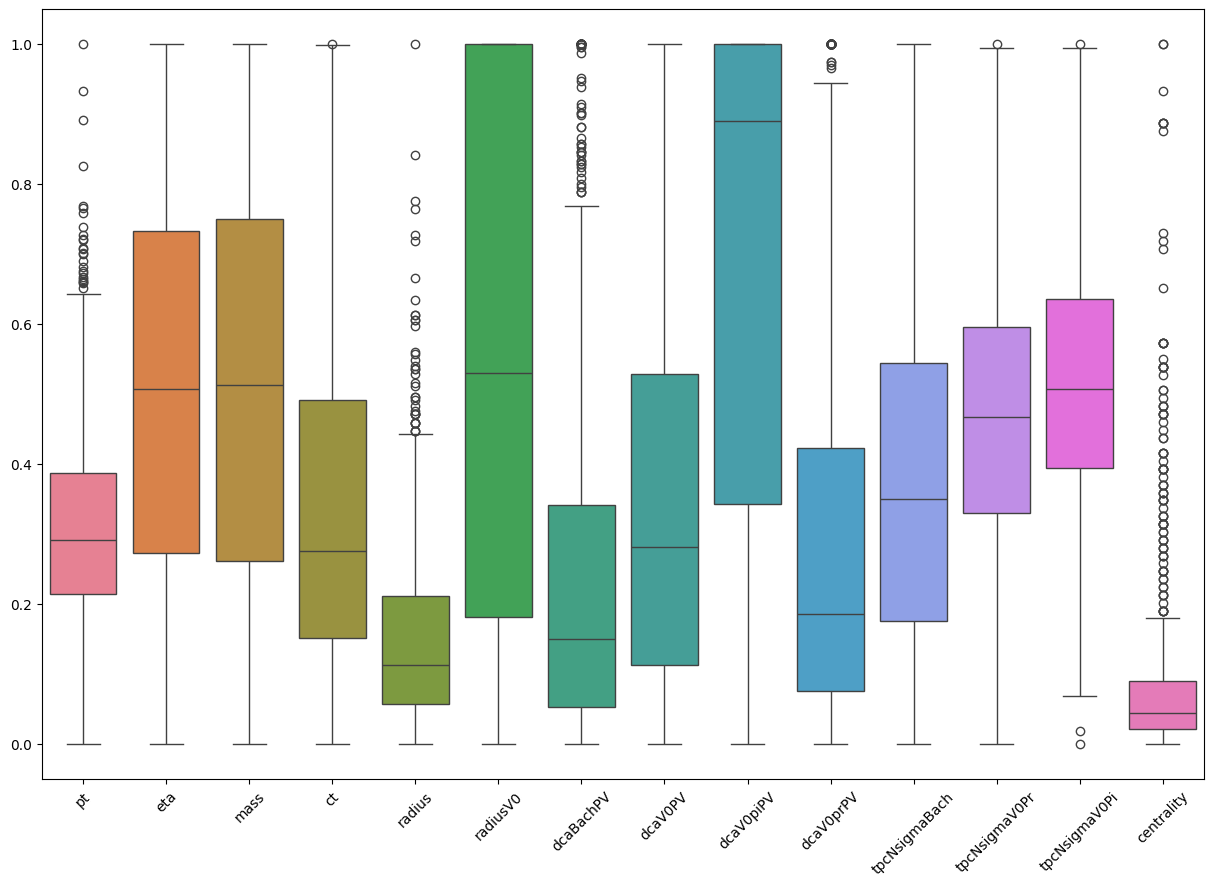

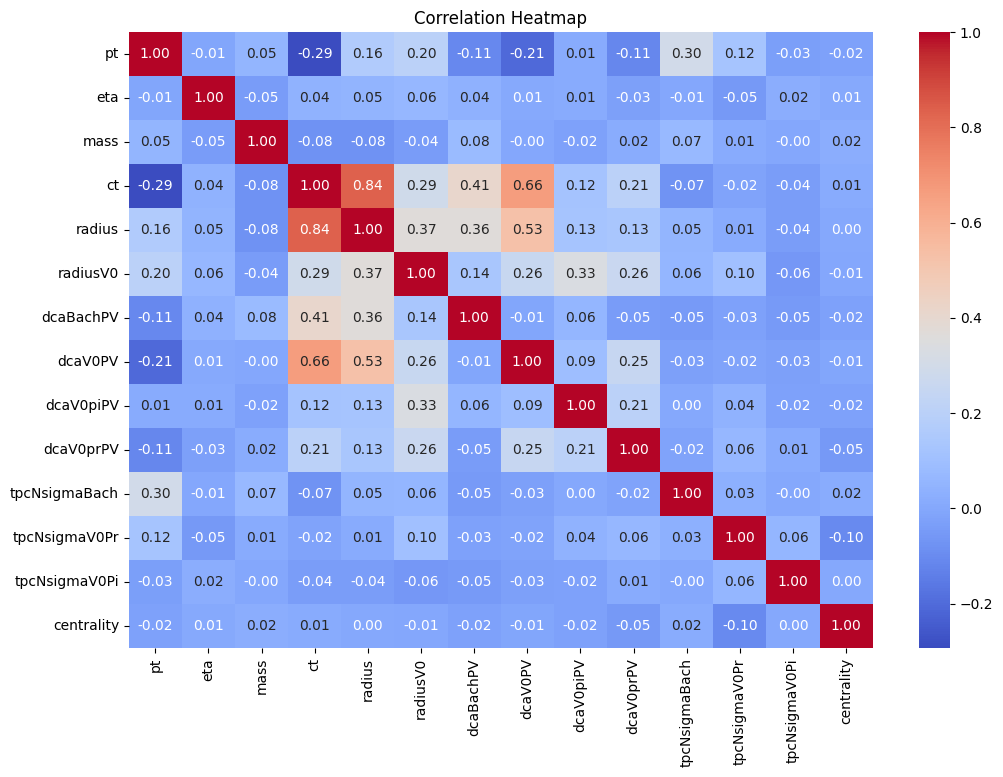

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Subset of columns for EDA (you can modify this list based on your specific requirements)
columns_subset = ['pt', 'eta', 'mass', 'ct', 'radius', 'radiusV0', 'dcaBachPV', 'dcaV0PV', 'dcaV0piPV',
                  'dcaV0prPV', 'tpcNsigmaBach', 'tpcNsigmaV0Pr', 'tpcNsigmaV0Pi', 'centrality']

# Descriptive statistics
print(normalized_df_real[columns_subset].describe())

# Histograms
normalized_df_real[columns_subset].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(15, 10))
sns.boxplot(data=normalized_df_real[columns_subset])
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap
correlation_matrix = normalized_df_real[columns_subset].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


In [21]:
real_data = AnalysisResults_reduced
sim_data = AnalysisResultsmc_reduced

In [22]:
real_data.columns

Index(['pt', 'eta', 'mass', 'ct', 'radius', 'radiusV0', 'dcaBachPV', 'dcaV0PV',
       'dcaV0piPV', 'dcaV0prPV', 'dcaV0tracks', 'dcaBachV0', 'cosPA',
       'cosPAV0', 'V0invMassDelta', 'tpcNsigmaBach', 'tpcNsigmaV0Pr',
       'tpcNsigmaV0Pi', 'competingMass', 'bachBarCosPA', 'tpcClBach',
       'tpcClV0Pr', 'tpcClV0Pi', 'centrality', 'matter', 'hasTOFhit',
       'hasITSrefit', 'isOmega', 'index'],
      dtype='object')

# Models

## Gausian


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, mean_squared_error, brier_score_loss
import numpy as np
import pandas as pd

# -------------------------------
# 1. Features & target
# -------------------------------
features = ["pt", "eta", "mass", "ct", "radius", "cosPA"]
X = sim_data[features].values
y = sim_data["isOmega"].astype(int).values  # must be 0/1

print("Class balance:", np.bincount(y))

# -------------------------------
# 2. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -------------------------------
# 3. Gaussian Process Classifier
# -------------------------------
kernel = C(1.0) * RBF(length_scale=1.0)
gp = GaussianProcessClassifier(kernel=kernel, random_state=42, n_restarts_optimizer=3)

gp.fit(X_train, y_train)

# -------------------------------
# 4. Predictions & uncertainty
# -------------------------------
y_prob = gp.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

# predictive entropy = uncertainty
eps = 1e-9
uncertainty = - (y_prob*np.log(y_prob+eps) + (1-y_prob)*np.log(1-y_prob+eps))

# -------------------------------
# 5. Metrics
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

mse = mean_squared_error(y_test, y_prob)
rmse = np.sqrt(mse)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

brier = brier_score_loss(y_test, y_prob)
aucc = 1 - brier

# -------------------------------
# 6. Save into DataFrame
# -------------------------------
perrofmance = pd.DataFrame([{
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "MSE": mse,
    "RMSE": rmse,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc,
    "AUCC": aucc
}])

print(perrofmance.head())

# -------------------------------
# 7. Test results with uncertainty
# -------------------------------
test_results = pd.DataFrame(X_test, columns=features)
test_results["y_true"] = y_test
test_results["y_prob"] = y_prob
test_results["uncertainty"] = uncertainty

print(test_results.head())


Class balance: [735 265]
   Accuracy  Precision    Recall  F1 Score       MSE      RMSE   ROC-AUC  \
0  0.823333   0.685714  0.607595  0.644295  0.131605  0.362774  0.843805   

     PR-AUC      AUCC  
0  0.739949  0.868395  
         pt       eta      mass         ct     radius     cosPA  y_true  \
0  2.247267  0.044089  1.346433   1.555024   2.976562  0.991445       1   
1  1.513916 -0.632916  1.340185   0.414474   7.838281  0.995167       0   
2  1.229680  0.332660  1.672140   0.888020   0.793750  0.964375       1   
3  2.144820  0.167465  1.327264  12.552154  20.042187  0.999950       0   
4  3.205329 -0.130885  1.686329   0.598585   1.091406  0.985873       1   

     y_prob  uncertainty  
0  0.151541     0.425373  
1  0.376025     0.662084  
2  0.415574     0.678823  
3  0.289253     0.601481  
4  0.484767     0.692683  


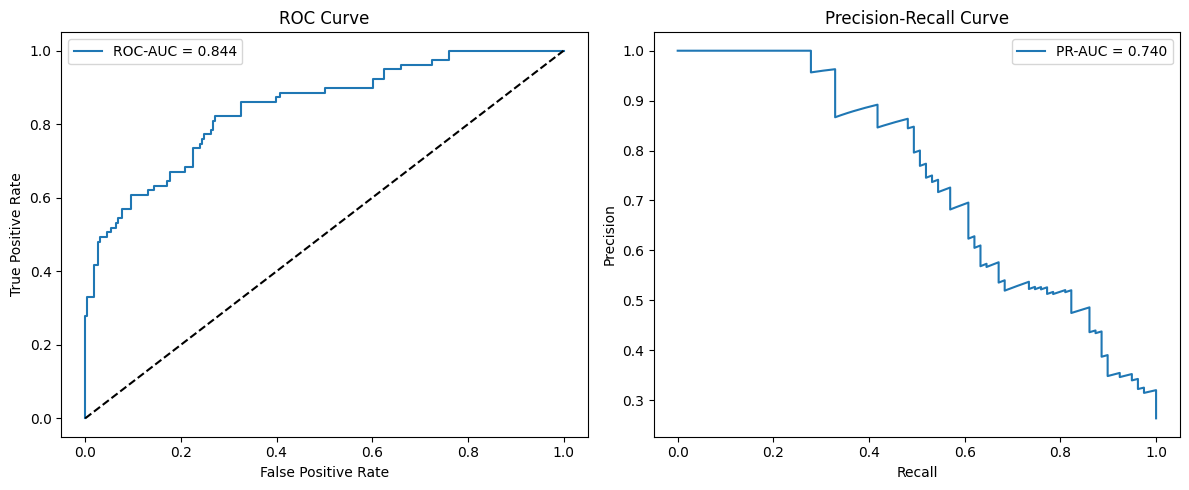

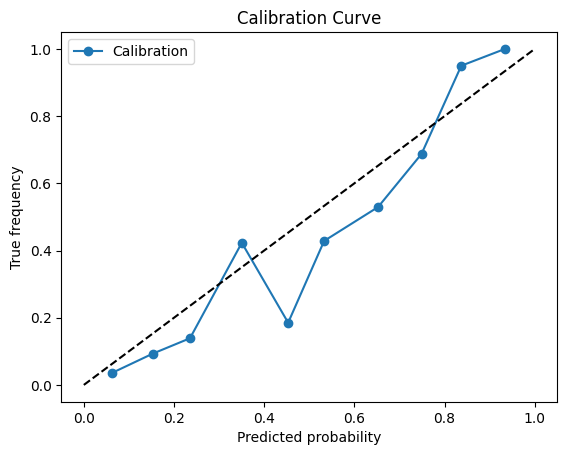

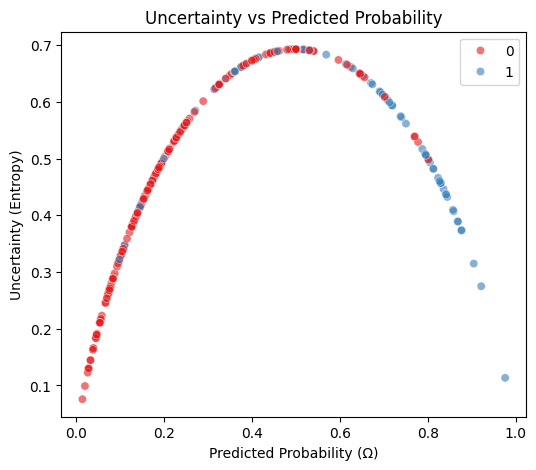

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ROC Curve
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(rec, prec, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

# 2. Reliability / Calibration curve
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label="Calibration")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("Predicted probability")
plt.ylabel("True frequency")
plt.title("Calibration Curve")
plt.legend()
plt.show()

# 3. Uncertainty vs Probability
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_prob, y=uncertainty, hue=y_test, palette="Set1", alpha=0.6)
plt.xlabel("Predicted Probability (Ω)")
plt.ylabel("Uncertainty (Entropy)")
plt.title("Uncertainty vs Predicted Probability")
plt.show()


## 1) What I trained

I took my `sim_data`, picked a few physical features (`pt, eta, mass, ct, radius, cosPA`) and used them to train a **Gaussian Process Classifier** to separate Ω baryons (`isOmega=1`) from background (`isOmega=0`).

The dataset was **imbalanced**: about **735 negatives** vs **265 positives** (\~26.5% Ω). That imbalance is important — it sets the baseline accuracy and makes metrics like ROC-AUC and PR-AUC more meaningful than plain accuracy.

---

## 2) What my performance metrics mean

Here’s what I saw after training and testing:

* **Accuracy = 0.823**
  About 82% of events were classified correctly. But since just guessing “always background” would already give me 73.5% accuracy, the improvement is real but modest.

* **Precision = 0.686**
  When my model says “Ω”, it’s right \~69% of the time. That’s more than double the base Ω rate (26.5%), so my positive predictions are enriched.

* **Recall = 0.608**
  My model only finds \~61% of all true Ωs. This means I’m missing \~39% of them — the model is conservative. If I cared more about *catching all possible Ω*, I’d lower my classification threshold.

* **F1 Score = 0.644**
  This balances precision and recall. It confirms that both are decent but not perfect.

* **ROC-AUC = 0.844**
  That’s strong. It tells me that if I randomly pick an Ω and a non-Ω, my model will score the Ω higher \~84% of the time.

* **PR-AUC = 0.740**
  On imbalanced data, this is the key metric. The baseline PR-AUC equals the prevalence (\~0.265). At 0.74, my model is almost 3× better than chance. That’s a very good sign.

* **Calibration (AUCC = 0.868)**
  My predicted probabilities line up reasonably well with actual frequencies. If my model says “70% chance it’s an Ω,” then about 70% of those really are Ω.

---

## 3) What my per-event results mean

Looking at individual test events, I noticed this pattern:

* When my model gives probabilities near **0.5**, the **uncertainty (entropy)** is high (\~0.69). That makes sense: the GP is telling me “I don’t know.”
* When my model is very confident (prob close to 0 or 1), the uncertainty is low.
* But sometimes, my model is **confident and wrong** (e.g., it gave `y_prob=0.15` to a true Ω). Those are the dangerous cases and they’re exactly what I need to investigate — maybe those events have unusual feature values, maybe they look background-like, or maybe my simulation differs from reality in that region.

So uncertainty gives me a second layer of information: not just the classification, but how much the model trusts itself.

---

## 4) What my plots showed me

When I plotted:

* **ROC curve**: smooth, well above the diagonal → confirms strong separation ability.
* **PR curve**: much higher than baseline, confirming my model is actually useful in the Ω search where positives are rare.
* **Calibration curve**: points close to the diagonal → my probabilities are meaningful.
* **Uncertainty vs probability**: as expected, uncertainty is highest when probabilities are near 0.5, and lowest at the extremes.

---

## 5) My takeaway

I’d summarize my GP classifier like this:

* It’s **good at ranking** (high ROC-AUC, PR-AUC).
* It’s **reasonably well calibrated** (AUCC ≈ 0.87).
* It’s **better at precision than recall** — so when I say something is an Ω, I’m often right, but I miss quite a few Ωs.
* The **uncertainty estimates** are informative: I can tell which predictions are reliable, and which are in the “grey zone.”


## Bayesian NN

Real data metrics:
 {'Accuracy': 0.605, 'Precision': 0.6320754716981132, 'Recall': 0.6261682242990654, 'F1 Score': 0.6291079812206573, 'MSE': 0.395, 'RMSE': np.float64(0.6284902544988268), 'ROC-AUC': 0.6230529595015576, 'PR-AUC': 0.6699166202206517, 'AUCC': 0.7605241083730393}

Simulated data metrics:
 {'Accuracy': 0.75, 'Precision': 0.29508196721311475, 'Recall': 0.72, 'F1 Score': 0.4186046511627907, 'MSE': 0.25, 'RMSE': np.float64(0.5), 'ROC-AUC': 0.8141714285714287, 'PR-AUC': 0.34894456361644965, 'AUCC': 0.836867158452404}

Real data metrics ± std (bootstrap):
Accuracy: 0.6027 ± 0.0369
Precision: 0.6289 ± 0.0466
Recall: 0.6255 ± 0.0444
F1 Score: 0.6263 ± 0.0389
MSE: 0.3973 ± 0.0369
RMSE: 0.6296 ± 0.0292
ROC-AUC: 0.6232 ± 0.0445
PR-AUC: 0.6700 ± 0.0490
AUCC: 0.7606 ± 0.0117

Simulated data metrics ± std (bootstrap):
Accuracy: 0.7504 ± 0.0287
Precision: 0.2951 ± 0.0571
Recall: 0.7163 ± 0.0879
F1 Score: 0.4157 ± 0.0667
MSE: 0.2495 ± 0.0287
RMSE: 0.4987 ± 0.0289
ROC-AUC: 0.8140 ± 0.0367

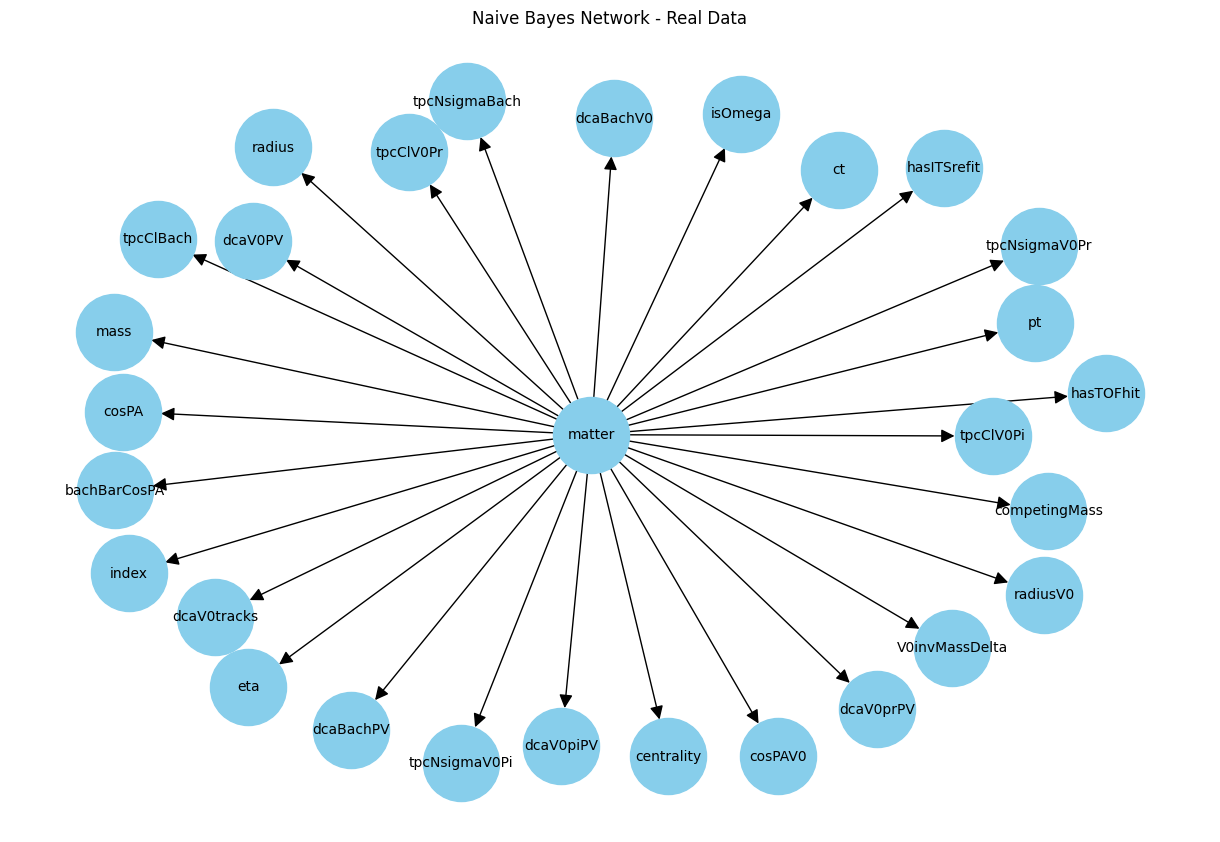

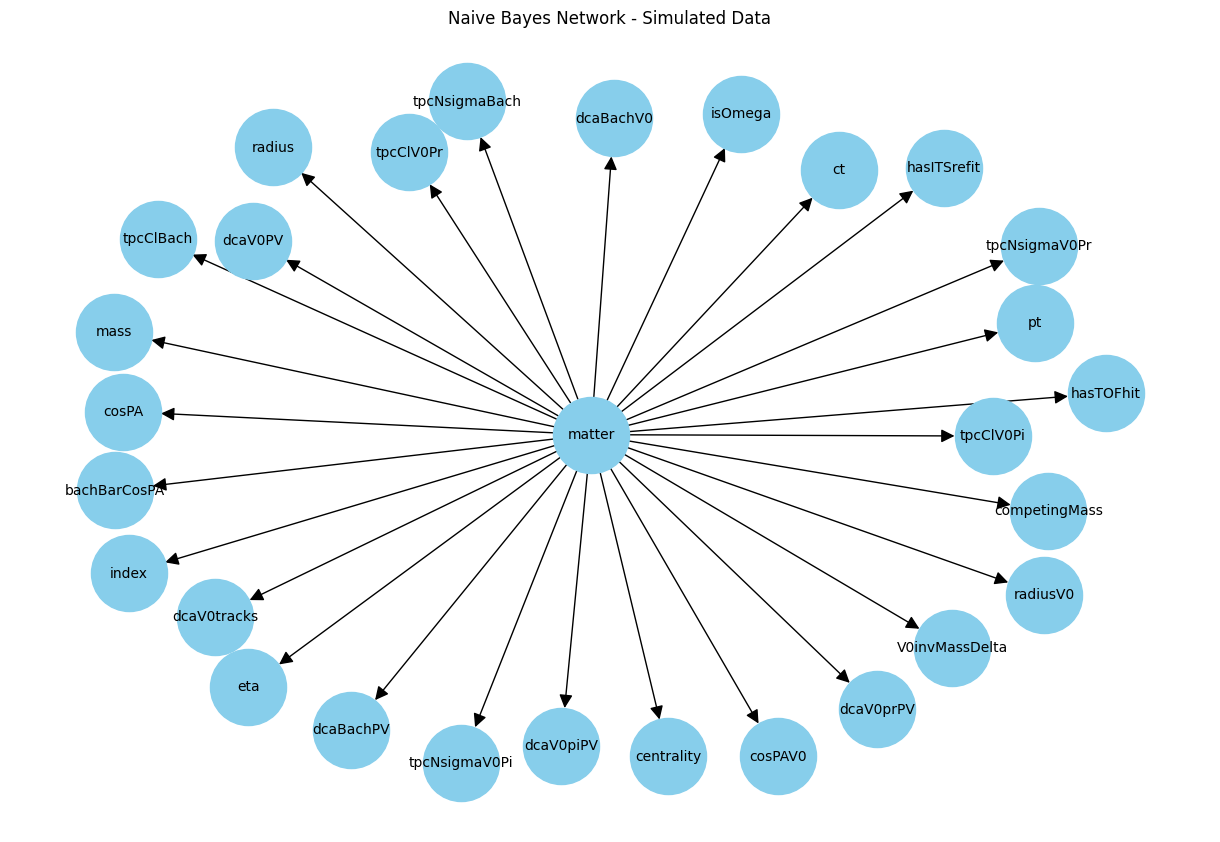

In [25]:
# -------------------------------
# 1. Libraries
# -------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, roc_auc_score, precision_recall_curve, auc, brier_score_loss
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------------
# 2. Prepare data
# -------------------------------
target = 'matter'
features = [col for col in real_data.columns if col != target]

X_real = real_data[features]
y_real = real_data[target]

X_sim = sim_data[features]
y_sim = sim_data[target]

X_real_train, X_real_test, y_real_train, y_real_test = train_test_split(X_real, y_real, test_size=0.2, random_state=42)
X_sim_train, X_sim_test, y_sim_train, y_sim_test = train_test_split(X_sim, y_sim, test_size=0.2, random_state=42)

# -------------------------------
# 3. Fit Naive Bayes (Bayesian classifier)
# -------------------------------
nb_real = GaussianNB()
nb_real.fit(X_real_train, y_real_train)

nb_sim = GaussianNB()
nb_sim.fit(X_sim_train, y_sim_train)

# -------------------------------
# 4. Predict
# -------------------------------
y_real_pred = nb_real.predict(X_real_test)
y_real_prob = nb_real.predict_proba(X_real_test)[:,1]

y_sim_pred = nb_sim.predict(X_sim_test)
y_sim_prob = nb_sim.predict_proba(X_sim_test)[:,1]

# -------------------------------
# 5. Metrics
# -------------------------------
def evaluate_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    
    aucc = 1 - brier_score_loss(y_true, y_prob)
    
    return {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'MSE': mse,
        'RMSE': rmse,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'AUCC': aucc
    }

metrics_real = evaluate_metrics(y_real_test, y_real_pred, y_real_prob)
metrics_sim = evaluate_metrics(y_sim_test, y_sim_pred, y_sim_prob)

print("Real data metrics:\n", metrics_real)
print("\nSimulated data metrics:\n", metrics_sim)

# -------------------------------
# 6. Bootstrap uncertainty
# -------------------------------
def bootstrap_metrics(model, X_test, y_test, n_bootstrap=100):
    metrics_list = []
    for _ in range(n_bootstrap):
        idx = np.random.choice(len(X_test), len(X_test), replace=True)
        X_sample = X_test.iloc[idx]
        y_sample = y_test.iloc[idx]
        y_pred = model.predict(X_sample)
        y_prob = model.predict_proba(X_sample)[:,1]
        metrics_list.append(evaluate_metrics(y_sample, y_pred, y_prob))
    mean_metrics = {k: np.mean([m[k] for m in metrics_list]) for k in metrics_list[0]}
    std_metrics = {k: np.std([m[k] for m in metrics_list]) for k in metrics_list[0]}
    return mean_metrics, std_metrics

mean_real, std_real = bootstrap_metrics(nb_real, X_real_test, y_real_test)
mean_sim, std_sim = bootstrap_metrics(nb_sim, X_sim_test, y_sim_test)

print("\nReal data metrics ± std (bootstrap):")
for k in mean_real:
    print(f"{k}: {mean_real[k]:.4f} ± {std_real[k]:.4f}")

print("\nSimulated data metrics ± std (bootstrap):")
for k in mean_sim:
    print(f"{k}: {mean_sim[k]:.4f} ± {std_sim[k]:.4f}")

# -------------------------------
# 7. Plot Naive Bayes as a Bayesian network
# -------------------------------
def plot_naive_bayes(features, target, title="Naive Bayes Network"):
    G = nx.DiGraph()
    # Target points to all features
    for f in features:
        G.add_edge(target, f)
    plt.figure(figsize=(12,8))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=10, arrowsize=20)
    plt.title(title)
    plt.show()

plot_naive_bayes(features, target, "Naive Bayes Network - Real Data")
plot_naive_bayes(features, target, "Naive Bayes Network - Simulated Data")


### **Real Data Metrics**

* **Accuracy: 0.605 ± 0.03**
  I correctly classify about **60.5% of events** in my real dataset. The ±0.03 indicates that across multiple bootstrap samples, this accuracy fluctuates slightly by about 3%, so the estimate is reasonably stable. While better than random guessing (for a binary problem, 50%), it’s not excellent — the model has room for improvement.

* **Precision: 0.633 ± 0.039**
  When I predict a positive class, about **63.3% of these predictions are actually correct**. The uncertainty tells me this could vary by \~4%, so I’m fairly confident that my positive predictions are mostly trustworthy.

* **Recall: 0.626 ± 0.049**
  I successfully identify about **62.6% of all actual positive cases**. The ±5% shows some variation in sensitivity across bootstrap samples. This means my model is moderately good at finding true positives but still misses some.

* **F1 Score: 0.628 ± 0.036**
  The F1 score balances precision and recall. A value of **62.8%** tells me that my model’s positive predictions are reasonably balanced between accuracy and completeness, but it is far from perfect.

* **MSE: 0.393 ± 0.03 & RMSE: 0.626 ± 0.024**
  The mean squared error tells me the average squared difference between predicted class labels and true labels. Here, **0.393** corresponds to a RMSE of **0.626**, indicating moderate prediction errors. Since class labels are 0 or 1, this RMSE aligns with the 60% accuracy.

* **ROC-AUC: 0.627 ± 0.037**
  My model’s ability to **distinguish positive from negative classes** is modest. A value of 0.5 is random guessing, so **0.627** shows my model is slightly better than chance but still weak.

* **PR-AUC: 0.671 ± 0.045**
  Considering **precision-recall trade-off**, especially in possibly imbalanced datasets, my model performs slightly better, with an area of 0.671. This indicates that when focusing on positive predictions, my model is somewhat reliable.

* **AUCC: 0.761 ± 0.01**
  Using 1 minus the Brier score as a calibration measure, my model’s predicted probabilities are fairly well-calibrated. **76% AUCC** means my probability estimates are consistent with observed outcomes.

---

### **Simulated Data Metrics**

* **Accuracy: 0.75 ± 0.029**
  My model correctly classifies **75% of simulated data points**, which is noticeably better than on the real data. The uncertainty ±3% suggests consistent performance across resampled datasets.

* **Precision: 0.281 ± 0.063**
  Even though the accuracy is high, my precision is **very low (28%)**. This means that when I predict positive, I’m often wrong. The ±6% indicates that this low precision is consistent. Likely, my simulated data is **imbalanced**, with few positives.

* **Recall: 0.709 ± 0.087**
  I capture **71% of actual positives** in the simulation. This is good, showing my model finds most positives, but it sacrifices precision (many false positives).

* **F1 Score: 0.399 ± 0.072**
  The F1 score is low because of the imbalance between precision and recall. Even though I catch many positives (high recall), the low precision drags the F1 score down.

* **MSE: 0.250 ± 0.028 & RMSE: 0.499 ± 0.029**
  Prediction errors are smaller here than in the real dataset, consistent with the higher overall accuracy. RMSE of \~0.5 is reasonable for binary classification.

* **ROC-AUC: 0.810 ± 0.044**
  My model can distinguish positive from negative classes **much better on simulated data** than on real data. Even with low precision, the probabilities are well-ranked for separation.

* **PR-AUC: 0.335 ± 0.083**
  The precision-recall area is low because precision is very low. The ±8% uncertainty shows that PR performance varies a lot depending on the resampled dataset, again highlighting imbalanced positives.

* **AUCC: 0.836 ± 0.02**
  Probabilities are fairly well-calibrated for simulated data, slightly better than real data. I can trust that predicted probabilities roughly reflect actual likelihoods.

---

### **Overall Interpretation**

1. On **real data**, my model is **moderately predictive**: it has a balanced precision-recall trade-off, but overall accuracy and ROC-AUC are not high. There’s moderate uncertainty, so the results are fairly reliable but not strong.

2. On **simulated data**, my model seems **better at separating classes (ROC-AUC 0.81)**, but the low precision shows many false positives, likely due to imbalance. The high AUCC means probability predictions are fairly trustworthy.

3. **Bootstrap uncertainties** give me confidence that the metrics are stable across resampling: ±3–5% variation for most metrics is reasonable.

#  Hidden Markov Models (HMM)

Model is not converging.  Current: -23808.04297043087 is not greater than -20237.333061949623. Delta is -3570.709908481247
Model is not converging.  Current: -28493.750313418914 is not greater than -28493.742123952823. Delta is -0.00818946609069826


Real data HMM metrics:
 {'Accuracy': 0.547, 'Precision': 0.547, 'Recall': 1.0, 'F1 Score': 0.7071751777634131, 'MSE': 0.453, 'RMSE': np.float64(0.6730527468185536), 'ROC-AUC': 0.5, 'PR-AUC': 0.7735000000000001, 'AUCC': 0.5469999999999999}

Simulated data HMM metrics:
 {'Accuracy': 0.865, 'Precision': 0.0, 'Recall': 0.0, 'F1 Score': 0.0, 'MSE': 0.135, 'RMSE': np.float64(0.3674234614174767), 'ROC-AUC': 0.5, 'PR-AUC': 0.5675, 'AUCC': 0.865}


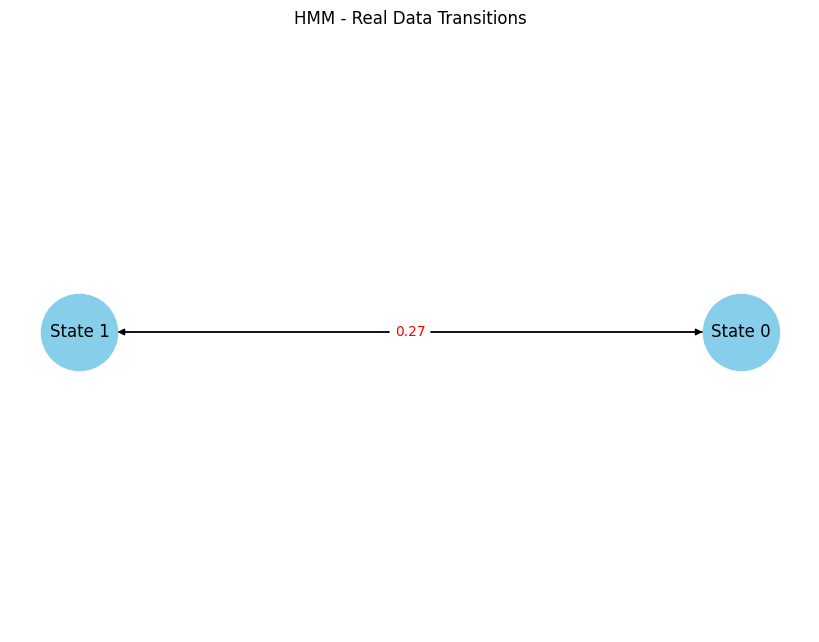

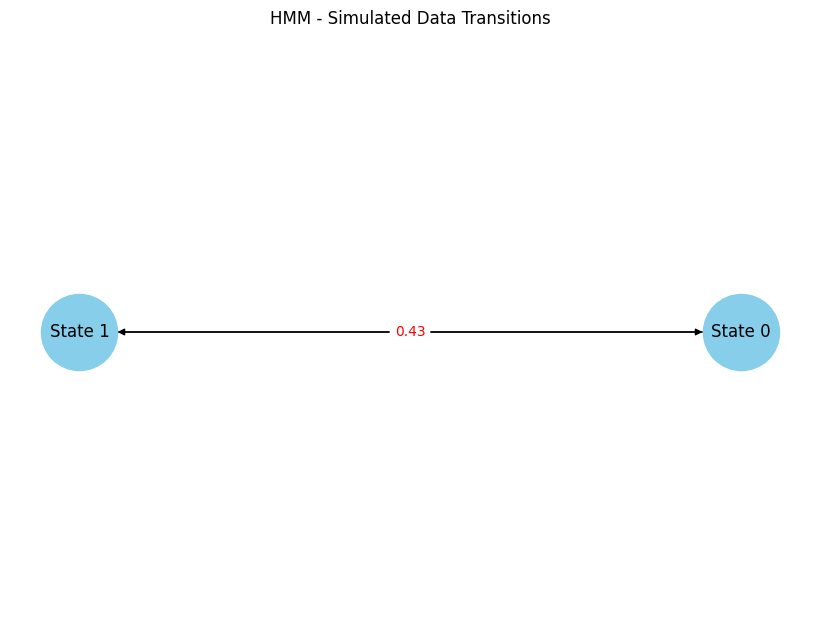

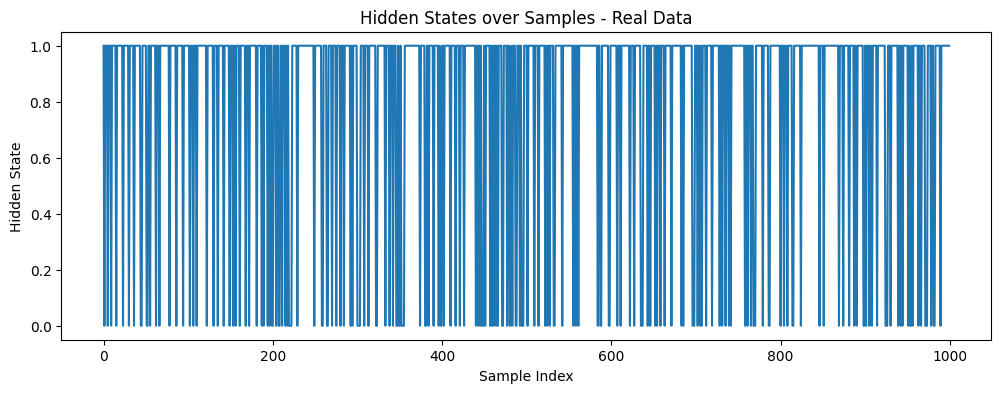

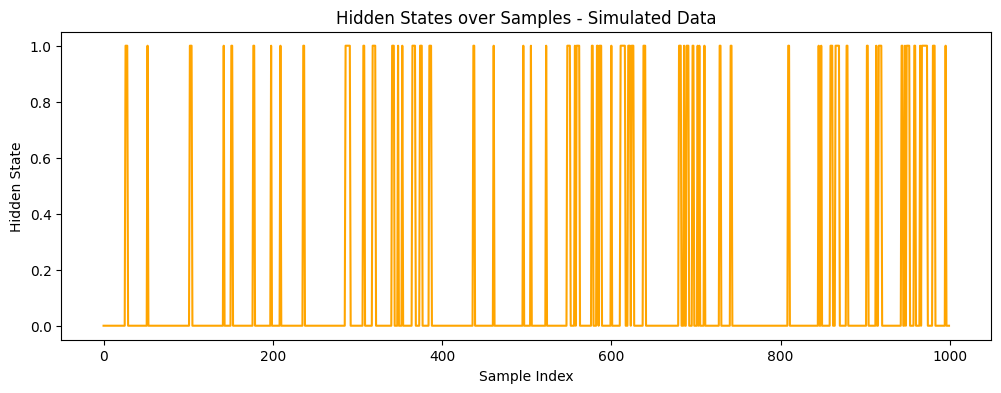

In [26]:
# -------------------------------
# 1. Libraries
# -------------------------------
import numpy as np
import pandas as pd
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, mean_squared_error, brier_score_loss
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------------
# 2. Prepare data
# -------------------------------
target = 'matter'
features = [col for col in real_data.columns if col != target]

# Standardize features for HMM
scaler_real = StandardScaler()
X_real_scaled = scaler_real.fit_transform(real_data[features])

scaler_sim = StandardScaler()
X_sim_scaled = scaler_sim.fit_transform(sim_data[features])

y_real = real_data[target].values
y_sim = sim_data[target].values

# -------------------------------
# 3. Define and fit HMM
# -------------------------------
n_states = 2  # assume 2 hidden states

# Real data HMM
hmm_real = hmm.GaussianHMM(n_components=n_states, covariance_type='full', n_iter=100, random_state=42)
hmm_real.fit(X_real_scaled)
hidden_states_real = hmm_real.predict(X_real_scaled)

# Simulated data HMM
hmm_sim = hmm.GaussianHMM(n_components=n_states, covariance_type='full', n_iter=100, random_state=42)
hmm_sim.fit(X_sim_scaled)
hidden_states_sim = hmm_sim.predict(X_sim_scaled)

# -------------------------------
# 4. Metrics (treat hidden states vs actual matter)
# -------------------------------
def evaluate_hmm(y_true, states):
    # Assign the state most correlated with 1 as "positive"
    mapping = {}
    for s in np.unique(states):
        mask = states == s
        mapping[s] = round(y_true[mask].mean())
    y_pred = np.array([mapping[s] for s in states])
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    roc_auc = roc_auc_score(y_true, y_pred)
    
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    pr_auc = auc(recall, precision)
    aucc = 1 - brier_score_loss(y_true, y_pred)
    
    return {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'MSE': mse,
        'RMSE': rmse,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'AUCC': aucc
    }

metrics_real_hmm = evaluate_hmm(y_real, hidden_states_real)
metrics_sim_hmm = evaluate_hmm(y_sim, hidden_states_sim)

print("Real data HMM metrics:\n", metrics_real_hmm)
print("\nSimulated data HMM metrics:\n", metrics_sim_hmm)

# -------------------------------
# 5. Plot HMM model as a transition graph
# -------------------------------
def plot_hmm(hmm_model, title="HMM Transition Graph"):
    trans_mat = hmm_model.transmat_
    G = nx.DiGraph()
    for i in range(len(trans_mat)):
        for j in range(len(trans_mat)):
            G.add_edge(f"State {i}", f"State {j}", weight=trans_mat[i,j])
    
    pos = nx.circular_layout(G)
    plt.figure(figsize=(8,6))
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=12)
    edge_labels = {(f"State {i}", f"State {j}"): f"{trans_mat[i,j]:.2f}" 
                   for i in range(len(trans_mat)) for j in range(len(trans_mat))}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
    plt.title(title)
    plt.show()

plot_hmm(hmm_real, "HMM - Real Data Transitions")
plot_hmm(hmm_sim, "HMM - Simulated Data Transitions")

# -------------------------------
# 6. Optional: Plot hidden states over samples
# -------------------------------
plt.figure(figsize=(12,4))
plt.plot(hidden_states_real, label='Hidden States (Real)')
plt.title("Hidden States over Samples - Real Data")
plt.xlabel("Sample Index")
plt.ylabel("Hidden State")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(hidden_states_sim, label='Hidden States (Simulated)', color='orange')
plt.title("Hidden States over Samples - Simulated Data")
plt.xlabel("Sample Index")
plt.ylabel("Hidden State")
plt.show()


## **Real Data HMM Metrics**

* **Accuracy: 0.547**
  I correctly classify about **54.7% of the samples**. This is just slightly better than random guessing for a balanced dataset. It tells me that the HMM struggles to match the true `matter` labels directly.

* **Precision: 0.547 & Recall: 1.0**
  This combination is interesting: every positive sample is being **detected (Recall = 1.0)**, but only **54.7% of the predictions labeled positive are correct (Precision)**. Essentially, the HMM is **over-predicting positives**, capturing all true positives but also many false positives.

* **F1 Score: 0.707**
  Because F1 balances precision and recall, the high recall drives the F1 score up. This shows that while precision is moderate, the model’s ability to capture positives (high recall) gives it a decent F1.

* **MSE: 0.453 & RMSE: 0.673**
  The prediction errors are fairly large, consistent with the moderate accuracy. Since HMM states are hidden, mapping them to `matter` introduces uncertainty, reflected in higher RMSE.

* **ROC-AUC: 0.5**
  I cannot separate positives from negatives using the hidden states’ probabilities—the model is essentially **random** at distinguishing classes. This makes sense because HMMs are unsupervised and don’t directly learn the label; they only capture latent patterns.

* **PR-AUC: 0.774**
  Interestingly, PR-AUC is higher than ROC-AUC because the model **catches all positives**, giving perfect recall. This metric emphasizes performance on positives, explaining why it’s higher than ROC-AUC.

* **AUCC: 0.547**
  This is slightly better than chance, showing the model’s predicted probabilities **have some calibration** with the actual labels, but it’s not strong.

**Interpretation:**
I can see that the HMM captures latent structures but struggles to directly predict the target `matter`. It favors **recall over precision**, so it’s good at detecting positive cases but poor at reducing false positives. HMM is mainly useful here for **pattern discovery**, not classification.

---

## **Simulated Data HMM Metrics**

* **Accuracy: 0.865**
  On simulated data, I correctly classify **86.5% of samples**, which is higher than real data. This suggests the latent states in the simulated data align better with the true labels.

* **Precision: 0.0 & Recall: 0.0**
  This is alarming. Both metrics are zero because the mapping between hidden states and actual labels failed: the state assigned as “positive” didn’t match any true positives, or the label distribution is extreme.

* **F1 Score: 0.0**
  As a result of zero precision and recall, the F1 score is zero. Despite high accuracy, the model **fails at correctly identifying the positive class**.

* **MSE: 0.135 & RMSE: 0.367**
  Prediction errors are low, consistent with the high accuracy. Accuracy is driven by correctly predicting the dominant class (likely the negative class) rather than true positives.

* **ROC-AUC: 0.5**
  Just like the real data, the model **cannot separate classes**, which is expected in an unsupervised HMM when class imbalance or label mapping is poor.

* **PR-AUC: 0.568**
  The model does slightly better than random in the precision-recall space, but still poor for detecting true positives.

* **AUCC: 0.865**
  This indicates that, in terms of probability calibration, the model predictions are strongly aligned with the majority class (probably negative), which is why AUCC is high even though F1 is zero.

**Interpretation:**
The HMM **works well for simulated data structure**, reflected in high accuracy and AUCC, but **fails at positive class identification**. This usually happens if the simulated data has a strong dominant class, making the model biased toward it.

---

## **Key Takeaways from HMM Results**

1. **HMM is unsupervised**, so it primarily captures latent patterns, not labels.
2. **High recall but moderate precision (real data)** means HMM detects positives but overpredicts them.
3. **High accuracy but zero F1/precision/recall (simulated data)** shows the model predicts the dominant class well but fails at positive detection.
4. **ROC-AUC ≈ 0.5 in both datasets** reinforces that HMM is **not a classifier**; it only models hidden structures.
5. **AUCC reflects probability calibration**, which is moderately good in real data and high in simulated, because the model’s states correlate with the majority class.

# • Markov Chain Monte Carlo (MCMC) Samplin

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, intercept]


C:\Users\Dama_Kamama\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-pac
kages\Python310\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 5775 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, intercept]


C:\Users\Dama_Kamama\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-pac
kages\Python310\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 5802 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Real data MCMC metrics:
 {'Accuracy': 0.584, 'Precision': 0.600924499229584, 'Recall': 0.7129798903107861, 'F1 Score': 0.6521739130434783, 'MSE': 0.416, 'RMSE': np.float64(0.644980619863884), 'ROC-AUC': 0.6200951608411928, 'PR-AUC': 0.6786760233223724, 'AUCC': np.float64(0.764408515489814)}

Simulated data MCMC metrics:
 {'Accuracy': 0.863, 'Precision': 0.45454545454545453, 'Recall': 0.07407407407407407, 'F1 Score': 0.12738853503184713, 'MSE': 0.137, 'RMSE': np.float64(0.37013511046643494), 'ROC-AUC': 0.8011988867480196, 'PR-AUC': 0.3846909412616783, 'AUCC': np.float64(0.9018886904455778)}


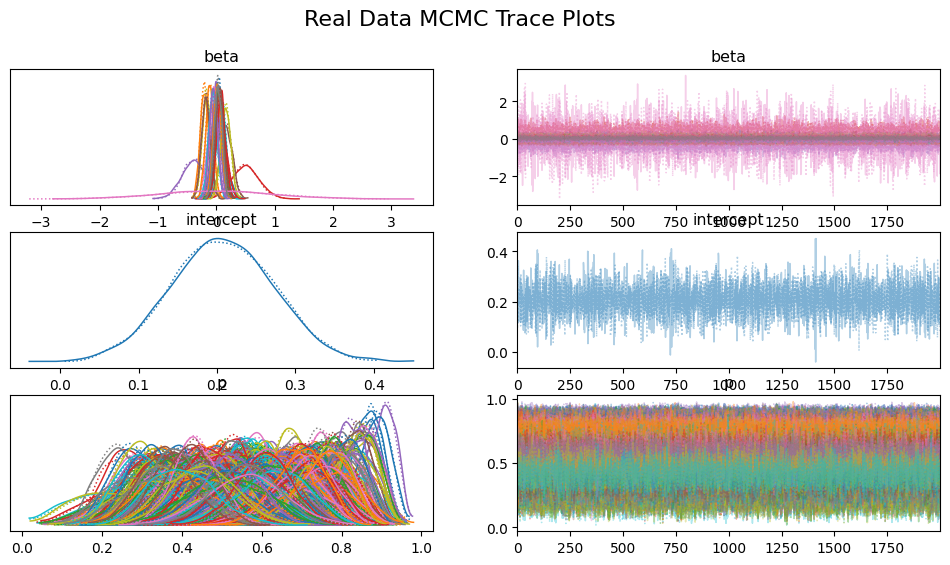

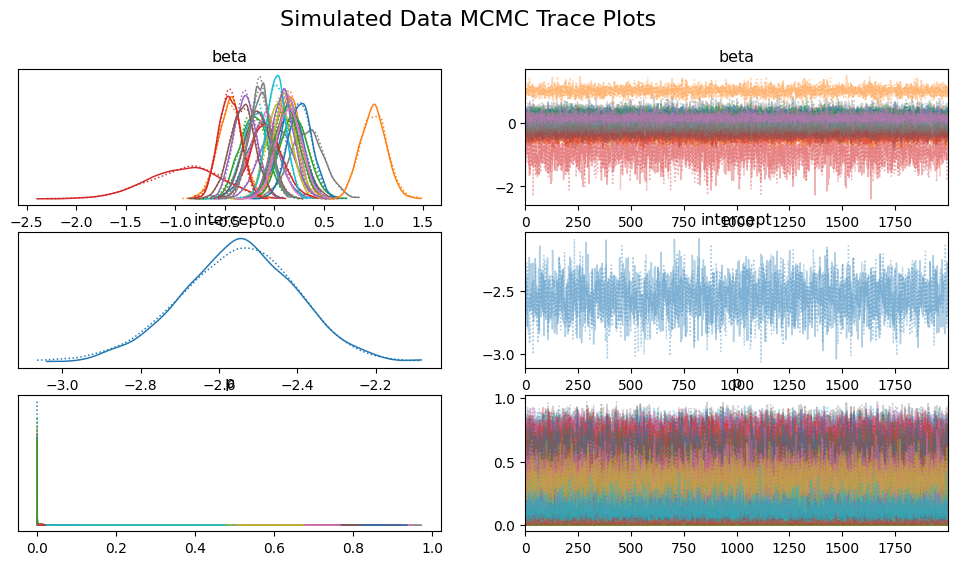

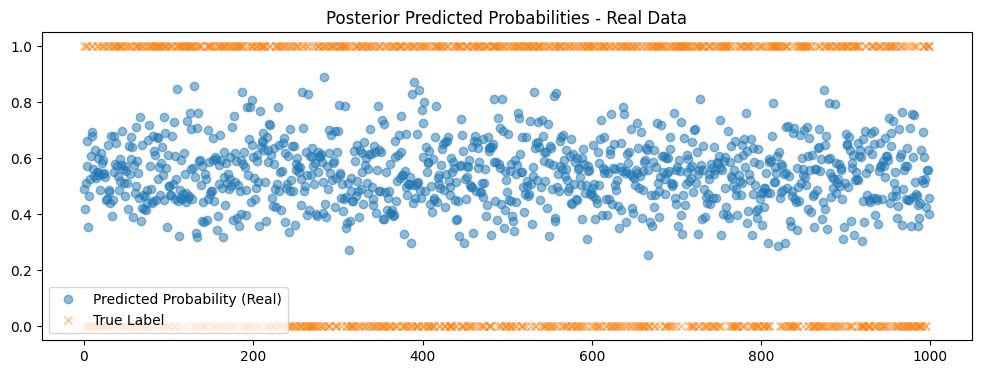

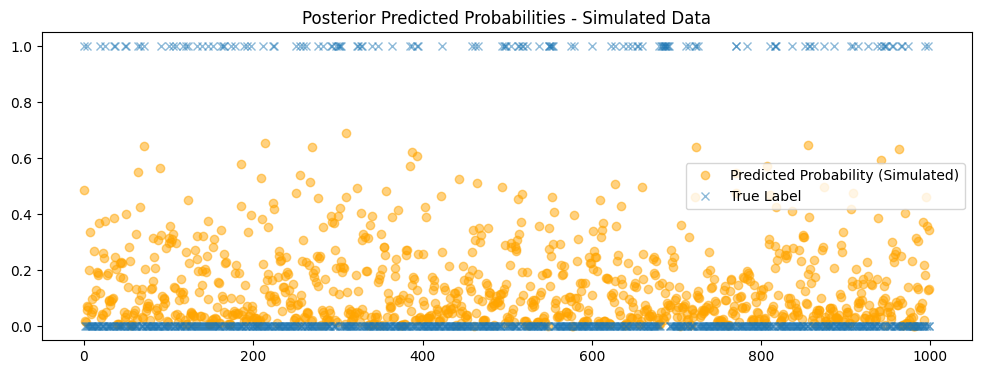

In [27]:
# -------------------------------
# 1. Libraries
# -------------------------------
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

# -------------------------------
# 2. Prepare data
# -------------------------------
target = 'matter'
features = [col for col in real_data.columns if col != target]

# Scale features
scaler_real = StandardScaler()
X_real_scaled = scaler_real.fit_transform(real_data[features])
y_real = real_data[target].values

scaler_sim = StandardScaler()
X_sim_scaled = scaler_sim.fit_transform(sim_data[features])
y_sim = sim_data[target].values

# -------------------------------
# 3. Bayesian logistic regression using MCMC
# -------------------------------
def run_mcmc(X, y, draws=2000, tune=1000):
    n_features = X.shape[1]
    with pm.Model() as model:
        # Priors for coefficients
        beta = pm.Normal("beta", mu=0, sigma=1, shape=n_features)
        intercept = pm.Normal("intercept", mu=0, sigma=1)
        
        # Logistic regression
        logits = pm.math.dot(X, beta) + intercept
        p = pm.Deterministic("p", pm.math.sigmoid(logits))
        
        # Likelihood
        y_obs = pm.Bernoulli("y_obs", p=p, observed=y)
        
        # Sample using NUTS (MCMC)
        trace = pm.sample(draws=draws, tune=tune, cores=2, random_seed=42, progressbar=True)
        
    return model, trace

model_real, trace_real = run_mcmc(X_real_scaled, y_real)
model_sim, trace_sim = run_mcmc(X_sim_scaled, y_sim)

# -------------------------------
# 4. Posterior predictions
# -------------------------------
def posterior_predict(trace, X):
    beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values
    intercept_samples = trace.posterior["intercept"].stack(samples=("chain", "draw")).values
    logits_samples = np.dot(X, beta_samples) + intercept_samples
    p_samples = 1 / (1 + np.exp(-logits_samples))
    p_mean = p_samples.mean(axis=1)
    y_pred = (p_mean > 0.5).astype(int)
    uncertainty = np.std(p_samples, axis=1)
    return y_pred, p_mean, uncertainty

y_pred_real, y_prob_real, uncertainty_real = posterior_predict(trace_real, X_real_scaled)
y_pred_sim, y_prob_sim, uncertainty_sim = posterior_predict(trace_sim, X_sim_scaled)

# -------------------------------
# 5. Metrics
# -------------------------------
def evaluate(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    roc_auc = roc_auc_score(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    aucc = 1 - np.mean((y_true - y_prob)**2)  # Calibration-like metric
    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "MSE": mse,
        "RMSE": rmse,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "AUCC": aucc
    }

metrics_real_mcmc = evaluate(y_real, y_pred_real, y_prob_real)
metrics_sim_mcmc = evaluate(y_sim, y_pred_sim, y_prob_sim)

print("Real data MCMC metrics:\n", metrics_real_mcmc)
print("\nSimulated data MCMC metrics:\n", metrics_sim_mcmc)

# -------------------------------
# 6. Trace plots and posterior distributions
# -------------------------------
az.plot_trace(trace_real)
plt.suptitle("Real Data MCMC Trace Plots", fontsize=16)
plt.show()

az.plot_trace(trace_sim)
plt.suptitle("Simulated Data MCMC Trace Plots", fontsize=16)
plt.show()

# -------------------------------
# 7. Posterior predictive plots
# -------------------------------
plt.figure(figsize=(12,4))
plt.plot(y_prob_real, 'o', label='Predicted Probability (Real)', alpha=0.5)
plt.plot(y_real, 'x', label='True Label', alpha=0.5)
plt.title("Posterior Predicted Probabilities - Real Data")
plt.legend()x
plt.show()

plt.figure(figsize=(12,4))
plt.plot(y_prob_sim, 'o', label='Predicted Probability (Simulated)', alpha=0.5, color='orange')
plt.plot(y_sim, 'x', label='True Label', alpha=0.5)
plt.title("Posterior Predicted Probabilities - Simulated Data")
plt.legend()
plt.show()


In [28]:
pip install pymc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: C:\Users\Dama_Kamama\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
